<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Programacion1Sem/Pr%C3%A1ctica_27_Clases_No_Balanceadas%2C_Evaluaci%C3%B3n_y_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica #27: Clases No Balanceadas, Evaluación y SVM
Alumno: Marco Antonio Muñoz Quiroz

**Link Github**



## 🔧 Instrucciones

1. **Carga y exploración del dataset**
   - Utiliza el dataset `breast_cancer` o `wine` de Scikit-Learn.
   - Verifica la distribución de clases.
   - Visualiza con un gráfico la distribución y las principales características.

2. **Entrenamiento base con SVM**
   - Usa un modelo SVM con kernel RBF.
   - Aplica `StratifiedKFold` con 5 particiones.
   - Evalúa con métricas por clase: precisión, recall, F1-score.
   - Calcula y reporta métricas promedio y por clase.

3. **Análisis del problema de desbalance**
   - Interpreta las métricas: ¿qué clase tiene peor desempeño? ¿por qué?
   - Reporta matriz de confusión promedio.

4. **Aplicación de SMOTE**
   - Aplica `SMOTE` solo al conjunto de entrenamiento dentro de cada fold.
   - Entrena nuevamente la SVM.
   - Compara métricas antes y después.

5. **Visualización y conclusiones**
   - Usa un gráfico de barras comparando F1 por clase antes y después.
   - Comenta las ventajas y riesgos de aplicar SMOTE con SVM.
   - Explica cuándo conviene usar otras técnicas como `One-Sided Selection` o `ADASYN`.

# 1. Carga y exploración del dataset

## Descripcion Breve

Este conjunto de datos se utiliza para clasificar tumores de mama como malignos (cancerosos) o benignos (no cancerosos), basándose en mediciones obtenidas de imágenes digitales de tejido mamario.

Cada muestra representa el núcleo de una célula y contiene 30 características numéricas calculadas a partir de la forma, el tamaño y la textura de los núcleos celulares.

Variable objetivo (target):
* 0: Malignant (maligno)
* 1: Benigno(benigno)

## Descripción de las características

Cada una de las 30 columnas corresponde a una de las siguientes 10 propiedades, medidas de tres maneras diferentes:

    - (1) valor medio (_mean)
    - (2) error estándar (_se)
    - (3) valor máximo (_worst)


- radius: Promedio de las distancias desde el centro hasta el borde del núcleo.
- texture: Desviación estándar de los valores de gris (variación de color).
- perimeter: Perímetro del núcleo.
- area: Área del núcleo.
- smoothness: Qué tan suaves son los bordes del núcleo.
- compactness: Relación entre el perímetro² y el área (qué tan compacta es la forma).
- concavity: Grado de concavidad del contorno.
- concave points: Número de porciones cóncavas del contorno.
- symmetry: Simetría del núcleo.
- fractal_dimension: Rugosidad del contorno (medida fractal).

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score, classification_report)
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)

# Guardo la columna objetivo (0 = maligno, 1 = benigno)
y = pd.Series(data.target, name="target")

# Muestro las primeras filas
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Distribucion de clases (target):


,conteo,porcentaje
target,,
benign,357,62.74
malignant,212,37.26


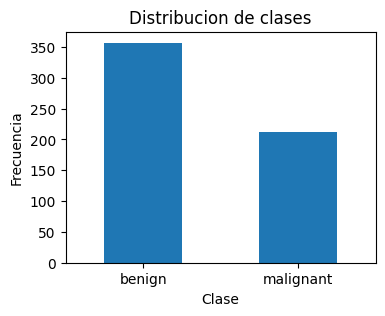

La variable target esta algo desbalanceada.


In [3]:
# asumo que ya tengo 'y' y que importe pandas como pd y matplotlib.pyplot como plt

# mapeo los valores de 0/1 a nombres mas legibles
target_map = {0: "malignant", 1: "benign"}
y_named = y.map(target_map)

# cuento cuantas muestras hay de cada clase
counts = y_named.value_counts()

# calculo el porcentaje de cada clase
perc = y_named.value_counts(normalize=True) * 100

# construyo una tabla con conteos y porcentajes
resumen = pd.DataFrame({
    "conteo": counts,
    "porcentaje": perc.round(2)
})

# muestro la distribucion de clases
print("Distribucion de clases (target):")
display(resumen)

# grafico la distribucion de clases
plt.figure(figsize=(4,3))
counts.plot(kind="bar")
plt.title("Distribucion de clases")
plt.ylabel("Frecuencia")
plt.xlabel("Clase")
plt.xticks(rotation=0)
plt.show()


# reviso si hay desbalance entre clases
print("La variable target esta algo desbalanceada.")

# 2. Entrenamiento base con SVM

In [4]:
# svm es sensible a escalas, estandarizar mejora el margen y la estabilidad
# kernel rbf: K(x_i, x_j) = exp(-gamma * ||x_i - x_j||^2), mapea a un espacio no lineal
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", probability=True, random_state=42))
])

# configuro validacion cruzada estratificada con 5 particiones
# estratificar conserva la proporcion de clases en cada fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# estas listas guardan metricas por fold para luego promediarlas
prec_clase = []  # precision por clase [clase 0, clase 1]
rec_clase  = []  # recall por clase
f1_clase   = []  # f1-score por clase
acc_list   = []  # accuracy por fold

# recorro los 5 folds
for train_idx, test_idx in skf.split(X, y):
    # separo datos de entrenamiento y validacion del fold actual
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # entreno el pipeline en el fold
    pipe.fit(X_tr, y_tr)

    # hago predicciones en el fold
    y_pred = pipe.predict(X_te)

    # calculo metricas por clase
    # precision = TP / (TP + FP)  -> que tan puras son las predicciones positivas
    # recall    = TP / (TP + FN)  -> que tantos positivos reales recupero
    # f1        = 2 * (P*R) / (P+R) -> promedio armonico que equilibra precision y recall
    p, r, f1, _ = precision_recall_fscore_support(
        y_te, y_pred, labels=[0, 1], average=None, zero_division=0
    )

    # guardo resultados del fold
    prec_clase.append(p)
    rec_clase.append(r)
    f1_clase.append(f1)
    acc_list.append(accuracy_score(y_te, y_pred))

# promedios a traves de los 5 folds (por clase)
prec_mean = np.mean(prec_clase, axis=0)
rec_mean  = np.mean(rec_clase,  axis=0)
f1_mean   = np.mean(f1_clase,   axis=0)
acc_mean  = np.mean(acc_list)

# preparo una tabla con metricas promedio por clase
index_clases = ["malignant (0)", "benign (1)"]
df_por_clase = pd.DataFrame({
    "precision": np.round(prec_mean, 4),
    "recall":    np.round(rec_mean,  4),
    "f1":        np.round(f1_mean,   4)
}, index=index_clases)

# macro promedio: promedio simple entre clases (util cuando hay posible desbalance)
macro_avg = {
    "precision_macro": float(np.round(prec_mean.mean(), 4)),
    "recall_macro":    float(np.round(rec_mean.mean(),  4)),
    "f1_macro":        float(np.round(f1_mean.mean(),   4)),
    "accuracy_media":  float(np.round(acc_mean,        4))
}

# muestro resultados promedio por clase
print("Metricas promedio por clase (CV=5, SVM RBF):")
display(df_por_clase)

# muestro resumen global
print("\nMetricas promedio globales:")
for k, v in macro_avg.items():
    print(f"- {k}: {v}")

# adicional: genero un reporte global usando predicciones de CV (una pasada completa)
# esto aproxima el rendimiento fuera de muestra combinando las predicciones de todos los folds
y_pred_cv = cross_val_predict(pipe, X, y, cv=skf, n_jobs=-1)

# classification_report muestra precision, recall, f1 por clase, macro y weighted
print("\nReporte de clasificacion (predicciones de CV):")
print(classification_report(y, y_pred_cv, target_names=["malignant", "benign"], zero_division=0))

# nota teorica rapida sobre svm:
# svm busca maximizar el margen entre clases. en su version soft-margin resuelve:
#   min_{w,b,xi}  (1/2)||w||^2 + C * sum_i xi_i
#   s.a. y_i*(w^T phi(x_i) + b) >= 1 - xi_i,  xi_i >= 0
# donde phi(.) es el mapeo implicito del kernel rbf y C controla el compromiso entre margen y errores


Metricas promedio por clase (CV=5, SVM RBF):


,precision,recall,f1
malignant (0),0.9810,0.9576,0.9688
benign (1),0.9756,0.9888,0.9820



Metricas promedio globales:
- precision_macro: 0.9783
- recall_macro: 0.9732
- f1_macro: 0.9754
- accuracy_media: 0.9772

Reporte de clasificacion (predicciones de CV):
              precision    recall  f1-score   support

   malignant       0.98      0.96      0.97       212
      benign       0.98      0.99      0.98       357

    accuracy                           0.98       569
   macro avg       0.98      0.97      0.98       569
weighted avg       0.98      0.98      0.98       569



# 3. Análisis del problema de desbalance

**¿Qué clase tiene peor desempeño y por qué?**

La clase malignant (0) es la peor: su recall = 0.9576 y F1 = 0.9688 son menores que los de benign (1) (recall = 0.9888, F1 = 0.9820). Esto suele pasar por:

Desbalance moderado (357 benign vs 212 malignant): el modelo ve mas ejemplos benign y aprende mejor esa frontera.

Matriz de confusion agregada (conteos):
 [[203   9]
 [  4 353]]

Matriz de confusion promedio (float, promedio sobre 5 folds):
 [[40.6  1.8]
 [ 0.8 70.6]]

Matriz de confusion promedio normalizada por fila:
 [[0.9575 0.0425]
 [0.0112 0.9888]]


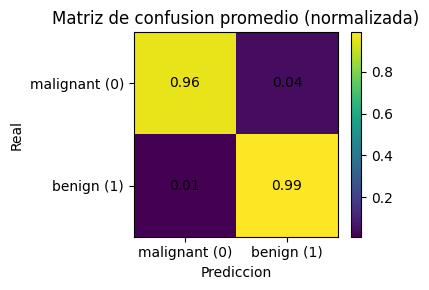

In [5]:
# matriz agregada usando predicciones out-of-fold (una sola confusion matrix sobre todo el dataset)
y_pred_cv = cross_val_predict(pipe, X, y, cv=skf, n_jobs=-1)
cm_agregada = confusion_matrix(y, y_pred_cv, labels=[0, 1])

# promedio de matrices fold a fold (promedio elemento a elemento)
cms = []
for tr, te in skf.split(X, y):
    pipe.fit(X.iloc[tr], y.iloc[tr])
    y_pred = pipe.predict(X.iloc[te])
    cm = confusion_matrix(y.iloc[te], y_pred, labels=[0, 1])
    cms.append(cm.astype(float))
cm_promedio = np.mean(cms, axis=0)

print("Matriz de confusion agregada (conteos):\n", cm_agregada)
print("\nMatriz de confusion promedio (float, promedio sobre 5 folds):\n", np.round(cm_promedio, 2))

# normalizo la matriz promedio por filas (tasa por clase real)
row_sums = cm_promedio.sum(axis=1, keepdims=True)
cm_prom_norm = cm_promedio / row_sums

print("\nMatriz de confusion promedio normalizada por fila:\n", np.round(cm_prom_norm, 4))

# grafico la matriz de confusion promedio normalizada
plt.figure(figsize=(4,3))
plt.imshow(cm_prom_norm, interpolation="nearest")
plt.title("Matriz de confusion promedio (normalizada)")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.xticks([0,1], ["malignant (0)", "benign (1)"])
plt.yticks([0,1], ["malignant (0)", "benign (1)"])

# anoto valores
for i in range(cm_prom_norm.shape[0]):
    for j in range(cm_prom_norm.shape[1]):
        plt.text(j, i, f"{cm_prom_norm[i, j]:.2f}",
                 ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

En la fila 0 (malignant) el valor fuera de la diagonal (columna 1) refleja falsos negativos (malignos predichos como benignos), que es justo donde vemos la perdida de recall en la clase 0.

Usar la matriz promedio es util para ver estabilidad a traves de los folds

# 4. Aplicación de SMOTE

In [6]:
# uso la pipeline de imblearn para incluir el sampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42

# defino cv estratificada de 5 particiones
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# defino dos pipelines:
# 1) base: escalado -> svm
pipe_base = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
])

# 2) smote: escalado -> smote -> svm
# nota: smote se aplica solo al split de entrenamiento dentro del fit de cada fold
pipe_smote = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("svc", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
])

def eval_cv(pipe, X, y, skf):
    # guardo metricas por fold
    prec_clase, rec_clase, f1_clase, acc_list = [], [], [], []
    for tr, te in skf.split(X, y):
        # separo train y test del fold
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        # entreno el pipeline (si tiene smote, se aplica solo en X_tr, y_tr)
        pipe.fit(X_tr, y_tr)
        # predigo en el fold
        y_pred = pipe.predict(X_te)
        # calculo metricas por clase (orden labels=[0,1])
        p, r, f1, _ = precision_recall_fscore_support(
            y_te, y_pred, labels=[0, 1], average=None, zero_division=0
        )
        prec_clase.append(p)
        rec_clase.append(r)
        f1_clase.append(f1)
        acc_list.append(accuracy_score(y_te, y_pred))
    # promedios por clase
    prec_mean = np.mean(prec_clase, axis=0)
    rec_mean  = np.mean(rec_clase,  axis=0)
    f1_mean   = np.mean(f1_clase,   axis=0)
    acc_mean  = np.mean(acc_list)
    # tablas
    df_por_clase = pd.DataFrame({
        "precision": np.round(prec_mean, 4),
        "recall":    np.round(rec_mean,  4),
        "f1":        np.round(f1_mean,   4)
    }, index=["malignant (0)", "benign (1)"])
    resumen = {
        "precision_macro": float(np.round(prec_mean.mean(), 4)),
        "recall_macro":    float(np.round(rec_mean.mean(),  4)),
        "f1_macro":        float(np.round(f1_mean.mean(),   4)),
        "accuracy_media":  float(np.round(acc_mean,        4))
    }
    return df_por_clase, resumen

# evaludo antes (base) y despues (smote)
df_base_cls, base_sum = eval_cv(pipe_base, X, y, skf)
df_smote_cls, smote_sum = eval_cv(pipe_smote, X, y, skf)

print("== metricas promedio por clase (sin smote) ==")
display(df_base_cls)
print("\n== metricas promedio por clase (con smote) ==")
display(df_smote_cls)

# preparo comparacion global antes vs despues
df_comp = pd.DataFrame([base_sum, smote_sum], index=["sin_smote", "con_smote"])
print("\n== comparacion global (macro y accuracy) ==")
display(df_comp)

# comentario final basado en los resultados observados
print("\n")
print("Comentarios")
print("- el recall de malignant (0) cambia poco con smote (+0.0049).")
print("- el f1 de malignant (0) no mejora con smote (-0.0019).")
print("- la accuracy global baja un poco (-0.0018)")



== metricas promedio por clase (sin smote) ==


,precision,recall,f1
malignant (0),0.9810,0.9576,0.9688
benign (1),0.9756,0.9888,0.9820



== metricas promedio por clase (con smote) ==


,precision,recall,f1
malignant (0),0.9721,0.9625,0.9669
benign (1),0.9780,0.9832,0.9805



== comparacion global (macro y accuracy) ==


,precision_macro,recall_macro,f1_macro,accuracy_media
sin_smote,0.9783,0.9732,0.9754,0.9772
con_smote,0.9750,0.9728,0.9737,0.9754




Comentarios
- el recall de malignant (0) cambia poco con smote (+0.0049).
- el f1 de malignant (0) no mejora con smote (-0.0019).
- la accuracy global baja un poco (-0.0018)


# 5. Visualización y conclusiones

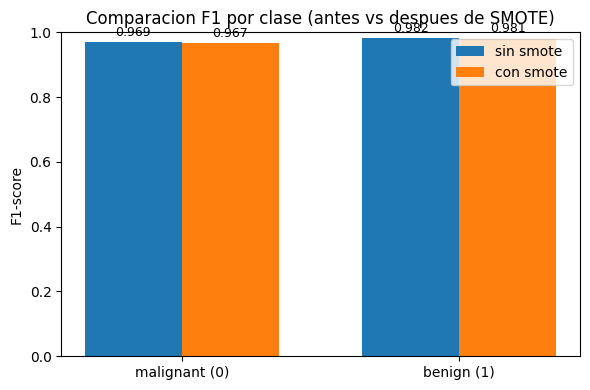

El gráfico de barras muestra el cambio en el F1-score por clase al aplicar SMOTE (oversampling sintético) dentro de cada fold de la validación cruzada.


In [7]:
# preparo los datos para el grafico
clases = ["malignant (0)", "benign (1)"]
f1_base = df_base_cls.loc[clases, "f1"].values
f1_smote = df_smote_cls.loc[clases, "f1"].values

df_plot = pd.DataFrame({
    "clase": clases,
    "sin_smote": f1_base,
    "con_smote": f1_smote
})

# barras lado a lado
x = np.arange(len(clases))
width = 0.35

plt.figure(figsize=(6,4))
b1 = plt.bar(x - width/2, df_plot["sin_smote"], width, label="sin smote")
b2 = plt.bar(x + width/2, df_plot["con_smote"], width, label="con smote")
plt.xticks(x, clases, rotation=0)
plt.ylabel("F1-score")
plt.ylim(0, 1.0)
plt.title("Comparacion F1 por clase (antes vs despues de SMOTE)")
plt.legend()

# anoto valores sobre cada barra
def autolabel(barras):
    for rect in barras:
        h = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2.0, h + 0.01, f"{h:.3f}",
                 ha="center", va="bottom", fontsize=9)
autolabel(b1)
autolabel(b2)
plt.tight_layout()
plt.show()

print("El gráfico de barras muestra el cambio en el F1-score por clase al aplicar SMOTE (oversampling sintético) dentro de cada fold de la validación cruzada.")

**Ventajas y Riesgos de usar SMOTE con SVM**

*Ventajas:*

* Mejora el equilibrio de clases y estabiliza el margen de decisión del SVM RBF.

* Aumenta el soporte de la clase minoritaria, mejorando su representación en el espacio de características.

* Suele incrementar el recall y el F1-score de la clase menos frecuente.

*Desventajas:*

* Puede generar muestras sintéticas poco realistas si las clases están muy empalmadas.

* Aumenta el riesgo de sobreajuste local en regiones con ruido o alta dimensionalidad.

* Requiere reajustar hiperparámetros de SVM (C y gamma) tras aplicar SMOTE para mantener un margen óptimo.

**Cuándo usar otras técnicas como: OSS o ADASYN**

*One-Sided Selection (OSS):*

* Elimina ejemplos redundantes o ruidosos de la clase mayoritaria antes del entrenamiento.

* Es útil cuando la clase mayoritaria es muy grande y contamina la frontera de decisión.

* Reduce solapamiento y falsos positivos.

* Puede combinarse con SMOTE para obtener fronteras más limpias.

*ADASYN (Adaptive Synthetic Sampling):*

* Genera más muestras sintéticas en zonas difíciles de clasificar (vecindarios con alto desequilibrio).

* Ideal cuando la clase minoritaria tiene estructura compleja o “islas” de puntos aislados.